## Planning Algorithms in AI 
## PS2: Sampling-based Planning

Student: Olga Tiupina

Problem: 

## Task I: Visualization

In [1]:
import numpy as np
import pickle
from environment import State, ManipulatorEnv
from rrt import RRTPlanner
from video_util import animate_plan
import matplotlib.pyplot as plt


### A

In [ ]:
# load data
with open("data.pickle", "rb") as f:
    data = pickle.load(f)

start_state = State(np.array(data["start_state"]))
goal_state = State(np.array(data["goal_state"]))

env = ManipulatorEnv(
    obstacles=np.array(data["obstacles"]),
    initial_state=start_state,
    collision_threshold=data["collision_threshold"]
)

# print("Start state angles:", start_state.angles)
# print("Start state joints:")
# print(start_state.joints)
# print("Goal state angles:", goal_state.angles)
# print("Goal state joints:")
# print(goal_state.joints)


[[ 2.5  1.   0.5]
 [ 1.5 -0.8  0.5]
 [-2.  -0.7  0.5]
 [-2.   1.5  0.5]
 [ 0.   1.2  0.5]
 [-0.3 -2.   0.7]]


In [22]:
# function to visualize a given state
def visualize_state(env, state, title="State"):
    env.state = state
    plt.figure(figsize=(6, 6))
    env.render(plt_show=False)
    plt.title(title)
    plt.show()

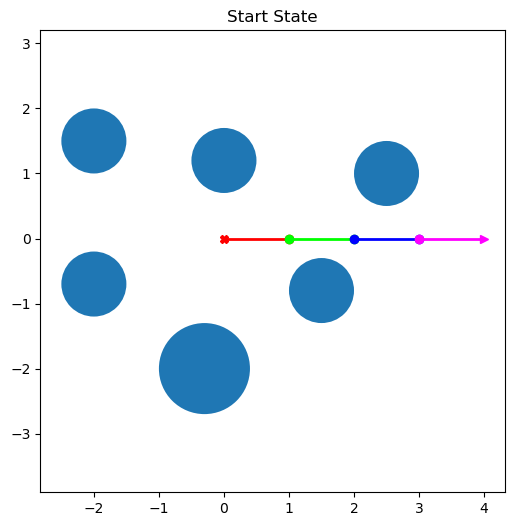

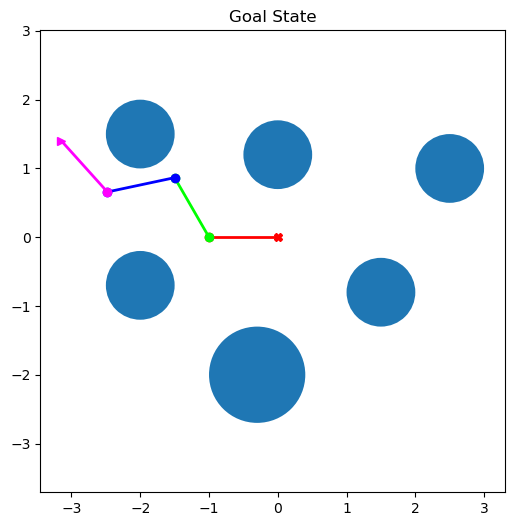

In [23]:
visualize_state(env, start_state, "Start State")
visualize_state(env, goal_state, "Goal State")


### Комментарий к пункту A
В предыдущем задании PS1 пространство ориентаций было **дискретным** (0, 45, 90, 135).  
В этом задании оно **непрерывное**, θ ∈ (−180°, 180°], что приводит к:

- бесконечному пространству конфигураций,
- более плавным и реалистичным движениям робота,
- необходимости использовать методы поиска в непрерывном пространстве (RRT, RRT\*\*, random sampling),
- более точной проверке коллизий.

То есть задача становится существенно сложнее, но и ближе к реальным роботам.


### B

In [ ]:
def random_state():
    q = np.random.uniform(-180, 180, size=4)
    return State(q)

# random_states = [random_state() for _ in range(4)] # генератор списка
random_states = []
for i in range(4):
    state = random_state()
    while i % 2 == 0 and env.check_collision(state):
        state = random_state()
    while i % 2 != 0 and not env.check_collision(state):
        state = random_state()
    random_states.append(state)



=== Random state 1 ===
Angles: [ -57.38554171 -111.85398165  146.60129964  171.27472309]
Collision: False


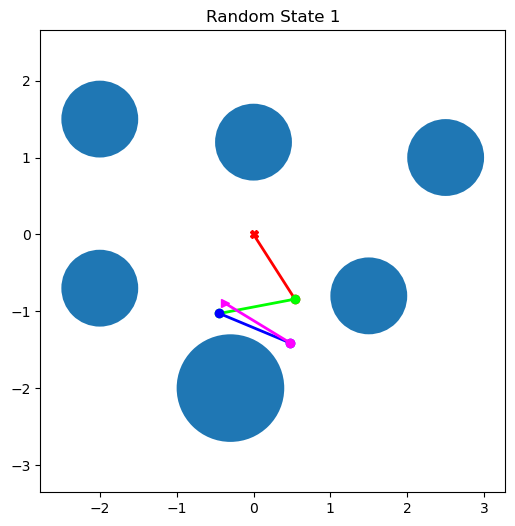


=== Random state 2 ===
Angles: [-170.0866601  -115.93469733 -102.9210641   106.89359439]
Collision: True


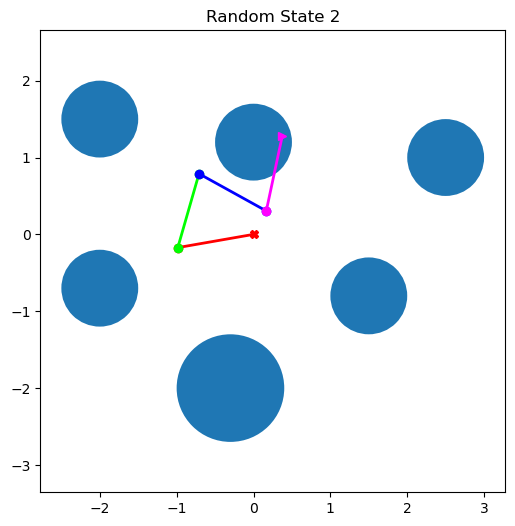


=== Random state 3 ===
Angles: [-153.88961962  -71.18438442   51.87450345  -61.69589   ]
Collision: False


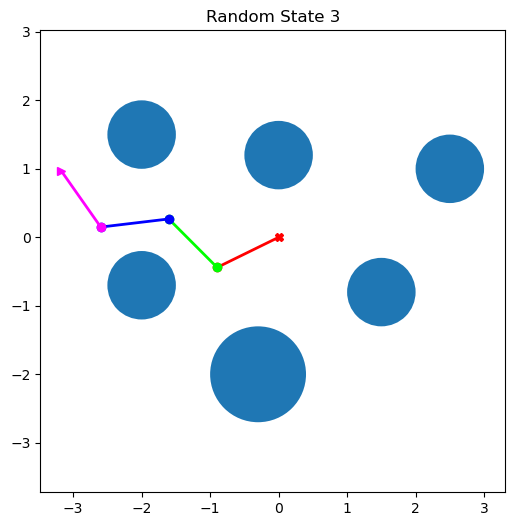


=== Random state 4 ===
Angles: [  45.39048838 -164.64838762 -144.05088213  120.8020502 ]
Collision: True


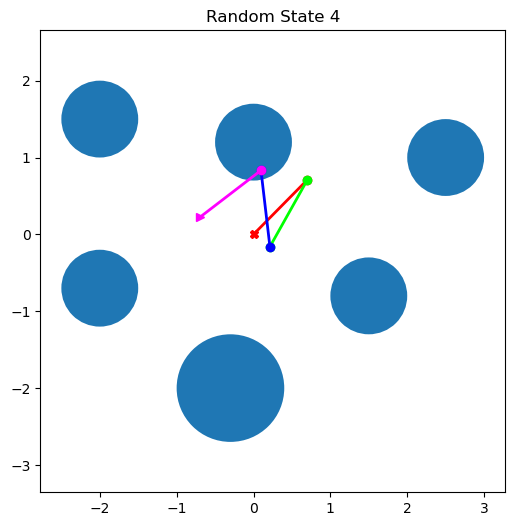

In [25]:
for i, st in enumerate(random_states, 1):
    print(f"\n=== Random state {i} ===")
    print("Angles:", st.angles)
    
    collision = env.check_collision(st)
    print("Collision:", collision)
    
    visualize_state(env, st, f"Random State {i}")


### Комментарий к пункту B

При визуализации заметно:

- Некоторые случайные конфигурации приводят к **столкновению**,
  когда звенья подходят ближе, чем `collision_threshold` к препятствию.
- Функция `check_collision()` корректно отлавливает:
  - касания концами звена,
  - пересечение середины звена (с помощью проекции на отрезок),
  - приближение к окружности.
- Пересечение звеньев **между собой** допускается — и это видно на рисунках.
- Геометрия манипулятора соответствует последовательному SE(2)-умножению, и изменения углов хорошо видны.

Таким образом, визуализация подтверждает корректность расчётов и проверки коллизий.


## Task II: Rapidly-exploring Random Trees (RRT)